# Physics-Informed Neural Network (PINN) for Burger's Equation

This project implements a Physics-Informed Neural Network (PINN) to solve the 1D **viscous Burger's equation** using PyTorch.

## Problem Statement

We aim to solve the nonlinear PDE:

\begin{equation*}
	u_t + u\,u_x = \nu\,u_{xx}
\end{equation*}


with:

- Domain: 

\begin{equation*}
	x \in [-1, 1], \quad t \in [0, 1]
\end{equation*}
 
- Initial condition: 

\begin{equation*}
	u(x, 0) = -\sin(\pi x)
\end{equation*}
- Boundary condition: 

\begin{equation*}
	u(-1, t) = u(1, t) = 0
\end{equation*}

---


In [2]:
import torch
import torch.nn as nn
import numpy as np  
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------
# 1. Define a feed-forward neural network 
# ---------------------------------------

class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__() #  initalize the base class
        self.net = nn.Sequential(
            *[nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh()) for i in range(len(layers)-2)], # Hidden layers with Tanh activation
            nn.Linear(layers[-2], layers[-1]) # Last layer without activation function
        )

    def forward(self, t, x):
        input = torch.cat([t, x], dim=1) # Concatenate time and space inputs
        return self.net(input)

1D **viscous Burger's equation**
\begin{equation*}
	u_t + u\,u_x - \nu\,u_{xx} = 0
\end{equation*}

In [ ]:
# ---------------------------------------------------
# 2. Compute residual of the PDE using Automatic Diff
# ---------------------------------------------------

# PDE residual for Burger's equation
def pde_residual(model, t, x, nu):
    u = model(t, x)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    return u_t + u * u_x - nu * u_xx # Residual of the PDE

In [5]:
# --------------------------
# 3. Data Generation 
# --------------------------

def generate_interior_points(N_f=10000, N_bc=100, N_ic=100):
    # Domain bounds 
    x_min, x_max = -1.0, 1.0
    t_min, t_max = 0.0, 1.0

    # interior points for PDE
    x_f = torch.rand(N_f, 1) * (x_max - x_min) + x_min # Randomly sample x in the domain
    t_f = torch.rand(N_f, 1) * (t_max - t_min) + t_min # Randomly sample t in the domain

    # Initial condition (t=0)
    x_ic = torch.linspace(x_min, x_max, N_ic).reshape(-1, 1) # Sample evenly spaced points in space
    t_ic = torch.zeros_like(x_ic) # Initial time is zero
    u_ic = -torch.sin(np.pi * x_ic) # Initial condition for u at t=0

    # Boundary condition (x = ±1)
    t_bc = torch.linspace(t_min, t_max, N_bc).reshape(-1, 1) # Sample evenly spaced points in time
    x_bc_left = x_min * torch.ones_like(t_bc) # Left boundary at x = -1
    x_bc_right = x_max * torch.ones_like(t_bc) # Right boundary at x = 1
    u_bc_left = torch.zeros_like(t_bc) # Boundary condition at x = -1 (u = 0)
    u_bc_right = torch.zeros_like(t_bc) # Boundary condition at x = 1 (u = 0)

    return x_f, t_f, x_ic, t_ic, u_ic, x_bc_left, t_bc, u_bc_left, x_bc_right, u_bc_right

In [ ]:
# ----------------------------------------
# 4. Define the Loss Components (PINN)
# ----------------------------------------
def loss_pde(model, t_f, x_f, nu): # Mean Squared Error of the PDE residual.
    f_pred = pde_residual(model, t_f, x_f, nu)
    return torch.mean(f_pred**2)

def loss_ic(model, t_ic, x_ic, u_ic): # MSE of the initial condition.
    u_pred = model(t_ic, x_ic)
    return torch.mean((u_pred - u_ic)**2)

def loss_bc(model, t_bc, x_bc, u_bc): # MSE of the boundary conditions.
    u_pred = model(t_bc, x_bc)
    return torch.mean((u_pred - u_bc)**2)

In [7]:
# ---------------------------------------
# 5. Training Setup
# ---------------------------------------
# Viscosity parameter
nu = 0.01 / np.pi

# Generate training data points
x_f, t_f, x_ic, t_ic, u_ic, x_bc_left, t_bc_vals, u_bc_left, x_bc_right, u_bc_right = generate_interior_points()

# Combine boundary points on both ends (Combines left and right boundary data into single tensors)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc = torch.cat([t_bc_vals, t_bc_vals], dim=0)
u_bc = torch.cat([u_bc_left, u_bc_right], dim=0)

# Enable gradients for PDE residual points (required for autograd)
x_f.requires_grad = True
t_f.requires_grad = True

# Define model architecture
layers = [2, 50, 50, 50, 1] # Input layer (t, x), three hidden layers with 50 neurons each, and output layer (u)
model = PINN(layers)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Learning rate for Adam optimizer

# Number of training epochs
num_epochs = 5000

In [8]:
# ---------------------------------------
# 6. Training Loop
# ---------------------------------------
for epoch in range(num_epochs):
    optimizer.zero_grad() # Reset gradients before each optimization step

    # Calculate losses
    pde_loss = loss_pde(model, t_f, x_f, nu)
    ic_loss = loss_ic(model, t_ic, x_ic, u_ic)
    bc_loss = loss_bc(model, t_bc, x_bc, u_bc)

    # Total loss
    loss = pde_loss + ic_loss + bc_loss

    # Backpropagation and optimization step
    loss.backward()
    optimizer.step()

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: PDE loss={pde_loss.item():.6f}, IC loss={ic_loss.item():.6f}, BC loss={bc_loss.item():.6f}, Total loss={loss.item():.6f}")

Epoch 0: PDE loss=0.001818, IC loss=0.456616, BC loss=0.004719, Total loss=0.463153
Epoch 500: PDE loss=0.043471, IC loss=0.055906, BC loss=0.000773, Total loss=0.100151
Epoch 1000: PDE loss=0.033299, IC loss=0.047579, BC loss=0.000291, Total loss=0.081169
Epoch 1500: PDE loss=0.025297, IC loss=0.029859, BC loss=0.000256, Total loss=0.055411
Epoch 2000: PDE loss=0.015099, IC loss=0.018330, BC loss=0.000226, Total loss=0.033654
Epoch 2500: PDE loss=0.010166, IC loss=0.010120, BC loss=0.000174, Total loss=0.020460
Epoch 3000: PDE loss=0.008298, IC loss=0.007175, BC loss=0.000117, Total loss=0.015590
Epoch 3500: PDE loss=0.007114, IC loss=0.006054, BC loss=0.000081, Total loss=0.013249
Epoch 4000: PDE loss=0.011048, IC loss=0.006126, BC loss=0.000077, Total loss=0.017251
Epoch 4500: PDE loss=0.005449, IC loss=0.004797, BC loss=0.000048, Total loss=0.010294


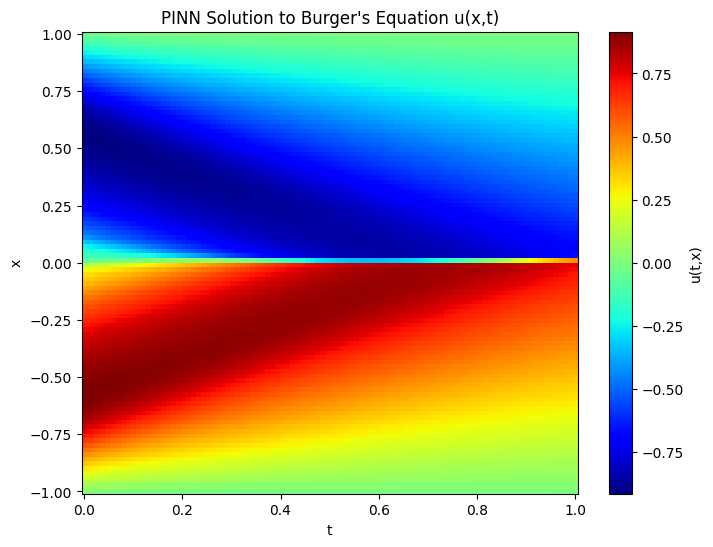

In [22]:
# ---------------------------------------
# 7. Evaluate the Trained Model
# ---------------------------------------
# Create mesh grid for visualization
t_test = torch.linspace(0, 1, 100).reshape(-1,1)
x_test = torch.linspace(-1, 1, 100).reshape(-1,1)
T, X = torch.meshgrid(t_test.squeeze(), x_test.squeeze(), indexing='ij')

t_test_flat = T.reshape(-1,1)
x_test_flat = X.reshape(-1,1)

# Predict solution on grid
model.eval()
with torch.no_grad():
    u_pred = model(t_test_flat, x_test_flat)

U_pred = u_pred.reshape(T.shape).cpu().numpy()

# Plot the results
plt.figure(figsize=(8,6))
plt.pcolormesh(T.cpu(), X.cpu(), U_pred, shading='auto', cmap='jet')
plt.colorbar(label='u(t,x)')
plt.xlabel('t')
plt.ylabel('x')
plt.title("PINN Solution to Burger's Equation u(x,t)")
plt.show() 